In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Códigos de conteúdo das células do grid
EMPTY = 0
DIRT = 1
OBSTACLE = 2


class VacuumEnvironment:
    """
    Ambiente de grade determinístico e parcialmente observável.
    O agente NÃO conhece de antemão o tamanho/limites do grid, a posição
    dos obstáculos nem a distribuição inicial de sujeira. A cada passo,
    ele só percebe: (1) se a célula em que está é suja e (2) se a última
    tentativa de movimento bateu em um obstáculo ou no limite do grid.
    """

    ACTIONS = ["Suck", "Up", "Down", "Left", "Right", "NoOp"]
    MOVES = {
        "Up": (-1, 0),
        "Down": (1, 0),
        "Left": (0, -1),
        "Right": (0, 1),
    }

    def __init__(self, rows, cols, dirt_cells, obstacle_cells, agent_pos):
        self.rows = rows
        self.cols = cols
        self.grid = np.full((rows, cols), EMPTY, dtype=int)
        for (r, c) in obstacle_cells:
            self.grid[r, c] = OBSTACLE
        for (r, c) in dirt_cells:
            if self.grid[r, c] != OBSTACLE:
                self.grid[r, c] = DIRT
        self.agent_pos = agent_pos
        self.bumped = False  # resultado da última tentativa de movimento

    def in_bounds(self, r, c):
        return 0 <= r < self.rows and 0 <= c < self.cols

    def percept(self):
        """Percepção local: sujeira na célula atual e se houve colisão."""
        r, c = self.agent_pos
        dirty = self.grid[r, c] == DIRT
        return {"dirty": dirty, "bump": self.bumped, "pos": (r, c)}

    def step(self, action):
        """
        Executa a ação do agente e atualiza o estado do ambiente.
        Retorna True se um movimento efetivo ocorreu (para custo de ação).
        """
        self.bumped = False
        moved = False
        r, c = self.agent_pos

        if action == "Suck":
            if self.grid[r, c] == DIRT:
                self.grid[r, c] = EMPTY
        elif action in self.MOVES:
            dr, dc = self.MOVES[action]
            nr, nc = r + dr, c + dc
            if self.in_bounds(nr, nc) and self.grid[nr, nc] != OBSTACLE:
                self.agent_pos = (nr, nc)
                moved = True
            else:
                self.bumped = True
        # NoOp: nenhuma alteração no ambiente

        return moved

    def clean_count(self):
        """Número de quadrados limpos (não sujos e não obstáculo)."""
        return int(np.sum(self.grid == EMPTY))


In [2]:
class SimpleReflexAgent:
    """
    Agente reativo simples (condição-ação).
    Decide a ação usando SOMENTE a percepção atual (sujeira, colisão),
    sem manter mapa ou histórico do ambiente. Ao colidir, escolhe uma
    nova direção aleatória; do contrário mantém a direção atual.
    """

    def __init__(self, seed=None):
        self.rng = random.Random(seed)
        self.direction = self.rng.choice(list(VacuumEnvironment.MOVES.keys()))

    def act(self, percept):
        # Regra 1: se a célula está suja, aspire
        if percept["dirty"]:
            return "Suck"
        # Regra 2: se bateu, escolha nova direção aleatória
        if percept["bump"]:
            self.direction = self.rng.choice(list(VacuumEnvironment.MOVES.keys()))
        # Regra 3: continue andando na direção atual
        return self.direction


class ModelBasedReflexAgent:
    """
    Agente reativo baseado em modelo.
    Mantém um modelo interno do ambiente: posição estimada (relativa ao
    ponto de partida, obtida por 'dead-reckoning' a partir das ações) e
    o estado conhecido de cada célula já visitada/detectada
    ('unknown', 'clean', 'dirty' ou 'obstacle'). Usa esse modelo para
    preferir explorar células desconhecidas ou sujas em vez de repetir
    células já limpas ou bater em obstáculos já conhecidos.
    """

    def __init__(self, seed=None):
        self.rng = random.Random(seed)
        self.pos = (0, 0)          # posição estimada no referencial próprio
        self.known = {self.pos: "unknown"}  # modelo interno do mundo
        self.last_action = None
        self.direction = self.rng.choice(list(VacuumEnvironment.MOVES.keys()))

    def _update_model(self, percept):
        # Atualiza a posição estimada / registra obstáculos conforme o
        # resultado da última ação de movimento tentada
        if self.last_action in VacuumEnvironment.MOVES:
            dr, dc = VacuumEnvironment.MOVES[self.last_action]
            destino = (self.pos[0] + dr, self.pos[1] + dc)
            if percept["bump"]:
                self.known[destino] = "obstacle"
            else:
                self.pos = destino

        # Atualiza o estado conhecido da célula atual
        self.known[self.pos] = "dirty" if percept["dirty"] else "clean"

    def _choose_direction(self):
        """Prioriza mover para célula desconhecida > suja > limpa; evita obstáculo."""
        candidatos = []
        for direcao, (dr, dc) in VacuumEnvironment.MOVES.items():
            destino = (self.pos[0] + dr, self.pos[1] + dc)
            estado = self.known.get(destino, "unknown")
            if estado == "obstacle":
                continue
            prioridade = {"unknown": 0, "dirty": 1, "clean": 2}[estado]
            candidatos.append((prioridade, direcao))

        if not candidatos:
            return self.rng.choice(list(VacuumEnvironment.MOVES.keys()))

        melhor_prioridade = min(candidatos, key=lambda x: x[0])[0]
        melhores = [d for p, d in candidatos if p == melhor_prioridade]
        return self.rng.choice(melhores)

    def act(self, percept):
        self._update_model(percept)

        if percept["dirty"]:
            acao = "Suck"
        else:
            self.direction = self._choose_direction()
            acao = self.direction

        self.last_action = acao
        return acao


In [3]:
def run_simulation(env, agent, max_steps=500, metric="M1"):
    """
    Executa a simulação por 'max_steps' períodos e acumula a pontuação
    segundo a métrica de desempenho escolhida:
      M1: +1 ponto por quadrado limpo, a cada período.
      M2: +1 ponto por quadrado limpo por período, -1 ponto por cada
          movimento efetivamente realizado pelo agente.
    """
    score = 0
    for _ in range(max_steps):
        percept = env.percept()
        action = agent.act(percept)
        moved = env.step(action)

        score += env.clean_count()
        if metric == "M2" and moved:
            score -= 1

    return score


In [4]:
def generate_configs(rows, cols, n_configs, dirt_ratio=0.3, obstacle_ratio=0.15, seed=0):
    """Gera várias configurações iniciais (sujeira, obstáculos, posição do agente)."""
    rng = random.Random(seed)
    todas_as_celulas = [(r, c) for r in range(rows) for c in range(cols)]
    configs = []

    for _ in range(n_configs):
        celulas = todas_as_celulas.copy()
        rng.shuffle(celulas)

        n_obs = int(len(celulas) * obstacle_ratio)
        obstacle_cells = celulas[:n_obs]
        restantes = [c for c in celulas if c not in obstacle_cells]

        n_dirt = int(len(restantes) * dirt_ratio)
        dirt_cells = restantes[:n_dirt]
        celulas_livres = [c for c in restantes if c not in dirt_cells]

        agent_pos = rng.choice(celulas_livres) if celulas_livres else restantes[0]

        configs.append({
            "dirt_cells": dirt_cells,
            "obstacle_cells": obstacle_cells,
            "agent_pos": agent_pos,
        })
    return configs


# Parâmetros fixos do experimento
ROWS, COLS = 6, 6
N_CONFIGS = 10
MAX_STEPS = 500

configs = generate_configs(ROWS, COLS, N_CONFIGS, seed=42)

agent_types = {
    "Reflexo Simples": SimpleReflexAgent,
    "Reflexo com Modelo": ModelBasedReflexAgent,
}
metrics = ["M1", "M2"]

resultados = []
for cfg_idx, cfg in enumerate(configs):
    for agent_name, AgentClass in agent_types.items():
        for metric in metrics:
            env = VacuumEnvironment(
                ROWS, COLS,
                cfg["dirt_cells"], cfg["obstacle_cells"], cfg["agent_pos"],
            )
            agent = AgentClass(seed=cfg_idx)
            score = run_simulation(env, agent, max_steps=MAX_STEPS, metric=metric)
            resultados.append({
                "config": cfg_idx,
                "agente": agent_name,
                "metrica": metric,
                "pontuacao": score,
            })

df = pd.DataFrame(resultados)
df


,config,agente,metrica,pontuacao
0,0,Reflexo Simples,M1,12745
1,0,Reflexo Simples,M2,12459
2,0,Reflexo com Modelo,M1,15277
3,0,Reflexo com Modelo,M2,14811
4,1,Reflexo Simples,M1,13315
5,1,Reflexo Simples,M2,13024
6,1,Reflexo com Modelo,M1,14903
7,1,Reflexo com Modelo,M2,14437
8,2,Reflexo Simples,M1,13272
9,2,Reflexo Simples,M2,12949


agente  Reflexo Simples          Reflexo com Modelo         
metrica              M1       M2                 M1       M2
config                                                      
0               12745.0  12459.0            15277.0  14811.0
1               13315.0  13024.0            14903.0  14437.0
2               13272.0  12949.0            15155.0  14690.0
3               12443.0  12095.0            15233.0  14767.0
4               13455.0  13142.0            15170.0  14706.0
5               12935.0  12629.0            15266.0  14801.0
6               15058.0  14747.0            15136.0  14671.0
7               12958.0  12633.0            15161.0  14694.0
8               14791.0  14452.0            15140.0  14676.0
9               14298.0  13984.0            15066.0  14600.0

,agente,metrica,pontuacao_media_global
0,Reflexo Simples,M1,13527.0
1,Reflexo Simples,M2,13211.4
2,Reflexo com Modelo,M1,15150.7
3,Reflexo com Modelo,M2,14685.3


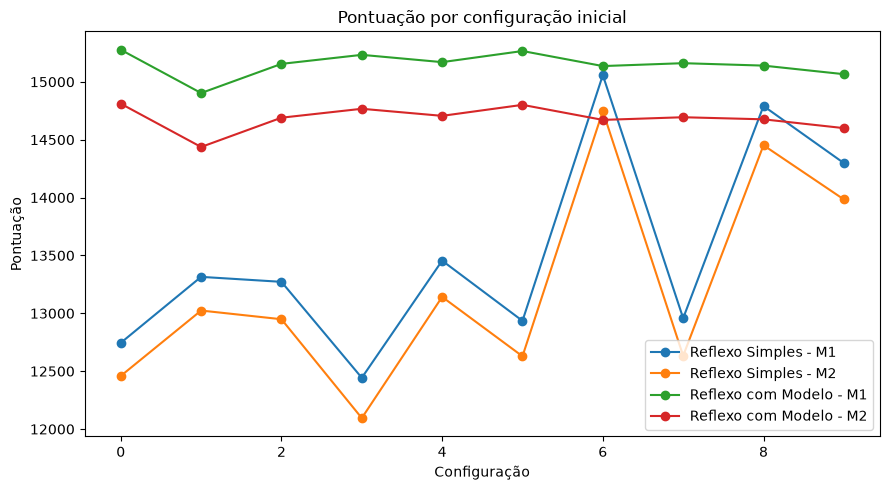

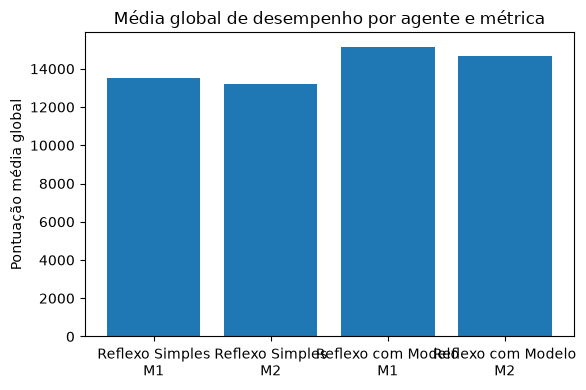

In [5]:
# Tabela: pontuação por configuração, agente e métrica
tabela = df.pivot_table(index="config", columns=["agente", "metrica"], values="pontuacao")
display(tabela)

# Tabela: média global por agente e métrica
media_global = (
    df.groupby(["agente", "metrica"])["pontuacao"]
    .mean()
    .reset_index()
    .rename(columns={"pontuacao": "pontuacao_media_global"})
)
display(media_global)

# Gráfico 1: pontuação por configuração, para cada agente/métrica
fig, ax = plt.subplots(figsize=(9, 5))
for (agente, metrica), grupo in df.groupby(["agente", "metrica"]):
    serie = grupo.set_index("config")["pontuacao"].sort_index()
    ax.plot(serie.index, serie.values, marker="o", label=f"{agente} - {metrica}")
ax.set_xlabel("Configuração")
ax.set_ylabel("Pontuação")
ax.set_title("Pontuação por configuração inicial")
ax.legend()
plt.tight_layout()
plt.show()

# Gráfico 2: média global por agente e métrica
fig2, ax2 = plt.subplots(figsize=(6, 4))
rotulos = [f"{a}\n{m}" for a, m in zip(media_global["agente"], media_global["metrica"])]
ax2.bar(rotulos, media_global["pontuacao_media_global"])
ax2.set_ylabel("Pontuação média global")
ax2.set_title("Média global de desempenho por agente e métrica")
plt.tight_layout()
plt.show()
